In [1]:
import sys
from importlib.abc import Loader, MetaPathFinder
from importlib.util import spec_from_loader

import nbimporter  # type: ignore


class _NbLoader(Loader):
    def __init__(self, legacy):
        self._legacy = legacy

    def create_module(self, spec):
        return self._legacy.load_module(spec.name)

    def exec_module(self, module):
        pass


class _NbFinder(MetaPathFinder):
    def find_spec(self, fullname, path=None, target=None):
        legacy = nbimporter.NotebookFinder().find_module(fullname, path)
        if legacy is None:
            return None
        return spec_from_loader(fullname, _NbLoader(legacy))


sys.meta_path.append(_NbFinder())


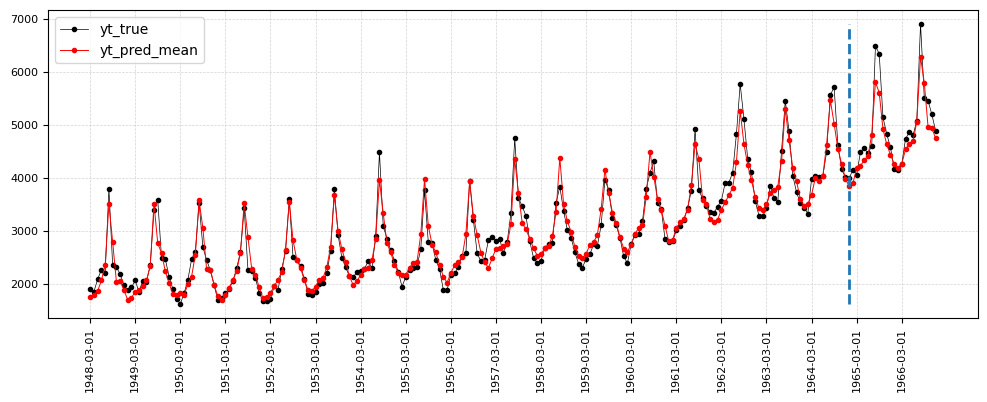

In [3]:
# =============================================================================
#
# Combinación de pronosticos
#
# =============================================================================
import warnings

warnings.filterwarnings("ignore")

#
# Carga de datos
#
import functions  # type: ignore
import pandas as pd  # type: ignore

#
# Promedio de los pronosticos
#
df_orig = pd.read_csv("../submission/forecasts.csv")
df_dropna = df_orig.dropna()
df_dropna = df_dropna.set_index("date")
df_dropna["yt_pred_mean"] = df_dropna.mean(axis=1)
functions.plot_time_series(df=df_dropna[["yt_true", "yt_pred_mean"]], yt_col="yt_true")
